<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ml-labs/UberKMeanClusteringWeek7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .master("local")\
        .appName("UberClusteringApp")\
        .enableHiveSupport()\
        .config('spark.ui.port', '4050')\
        .getOrCreate()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = spark.read.csv('/content/drive/MyDrive/UEL/uber.csv',inferSchema=True, header =True)

In [5]:
df.show(5)

+----------------+-------+--------+------+
|       Date/Time|    Lat|     Lon|  Base|
+----------------+-------+--------+------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|
+----------------+-------+--------+------+
only showing top 5 rows



In [6]:
from pyspark.ml.feature import VectorAssembler
cols = ["Lat", "Lon"]

assembler=VectorAssembler(inputCols=cols, outputCol="features")
featureDf = assembler.transform(df)
featureDf.printSchema()
featureDf.show(10)

root
 |-- Date/Time: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Lon: double (nullable = true)
 |-- Base: string (nullable = true)
 |-- features: vector (nullable = true)

+----------------+-------+--------+------+------------------+
|       Date/Time|    Lat|     Lon|  Base|          features|
+----------------+-------+--------+------+------------------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|
|5/1/2014 0:20:00|40.7685|-73.8625|B02512|[40.7685,-73.8625]|
|5/1/2014 0:21:00|40.7637|-73.9962|B02512|[40.7637,-73.9962]|
|5/1/2014 0:21:00|40.7252|-74.0023|B02512|[40.7252,-74.0023]|
|5/1/2014 0:25:00|40.7607|-73.9625|B02512|[40.7607,-73.9625]|
|5/1/2014 0:25:00|40.7212|-73.9879|B02512|[40.7212,-73.9879]|
+

In [7]:
featureDf.count()
trainingData, testData = featureDf.randomSplit([0.7, 0.3], seed = 5043)

print("Training Dataset Count: " + str(trainingData.count()))

print("Test Dataset Count: " + str(testData.count()))

Training Dataset Count: 412740
Test Dataset Count: 177136


**determing the cost for cluster numbers to find the right number of clusters**

In [8]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
cluster_count = [10,30,50,70,90]
for i in cluster_count:
  kmeans = KMeans().setK(i).setSeed(1).setFeaturesCol("features").setPredictionCol("prediction")
  kmeansModel = kmeans.fit(trainingData)
  for clusters in kmeansModel.clusterCenters():
    print(clusters)
  # test the model with test data set
  predictDf = kmeansModel.transform(testData)
  predictDf.show(10)
  evaluator = ClusteringEvaluator()
  silhouette = evaluator.evaluate(predictDf)
  print("Silhouette with squared euclidean distance = " + str(silhouette))

[ 40.75594193 -73.98142065]
[ 40.68714559 -73.96357832]
[ 40.70272262 -74.18006281]
[ 40.77573924 -73.86900296]
[ 40.63607673 -74.4246566 ]
[ 40.65361395 -73.78331751]
[ 40.72752081 -74.00011713]
[ 40.77666415 -73.52427637]
[ 40.78261028 -73.95813311]
[ 41.0096173  -73.72594773]
+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:01:00| 40.694|-73.9872|B02598| [40.694,-73.9872]|         1|
|5/1/2014 0:01:00|40.7684|-73.8624|B02617|[40.7684,-73.8624]|         3|
|5/1/2014 0:02:00|40.7206| -73.989|B02598| [40.7206,-73.989]|         6|
|5/1/2014 0:02:00|40.7509|-74.0036|B02617|[40.7509,-74.0036]|         0|
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|         0|
|5/1/2014 0:02:00|40.7746|-73.8997|B02682|[40.7746,-73.8997]|         3|
|5/1/2014 0:03:00|40.7437|-73.9876|B02682|[40.7437,-73.9876]|  

In [9]:
# test the model with test data set
predictDf = kmeansModel.transform(testData)
predictDf.show(10)
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(predictDf)
print("Silhouette with squared euclidean distance = " + str(silhouette))

+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:01:00| 40.694|-73.9872|B02598| [40.694,-73.9872]|        38|
|5/1/2014 0:01:00|40.7684|-73.8624|B02617|[40.7684,-73.8624]|        14|
|5/1/2014 0:02:00|40.7206| -73.989|B02598| [40.7206,-73.989]|        85|
|5/1/2014 0:02:00|40.7509|-74.0036|B02617|[40.7509,-74.0036]|        88|
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|        67|
|5/1/2014 0:02:00|40.7746|-73.8997|B02682|[40.7746,-73.8997]|        77|
|5/1/2014 0:03:00|40.7437|-73.9876|B02682|[40.7437,-73.9876]|        83|
|5/1/2014 0:04:00|40.7313|-73.9747|B02682|[40.7313,-73.9747]|        76|
|5/1/2014 0:04:00|40.7418|-74.0043|B02598|[40.7418,-74.0043]|        88|
|5/1/2014 0:05:00|40.6448|-73.7826|B02598|[40.6448,-73.7826]|         4|
+----------------+-------+--------+------+---------

In [10]:
predictDf.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|        31|  152|
|        85| 3456|
|        65|   81|
|        53| 6238|
|        78|   89|
|        34|  354|
|        81|   92|
|        28|   19|
|        76| 2369|
|        27| 3291|
|        26|   42|
|        44|  111|
|        12|  747|
|        22|    9|
|        47| 1062|
|         1| 1365|
|        52|   79|
|        13|   55|
|        86| 1359|
|        16| 4409|
+----------+-----+
only showing top 20 rows



In [11]:
pddf_pred = predictDf.toPandas()

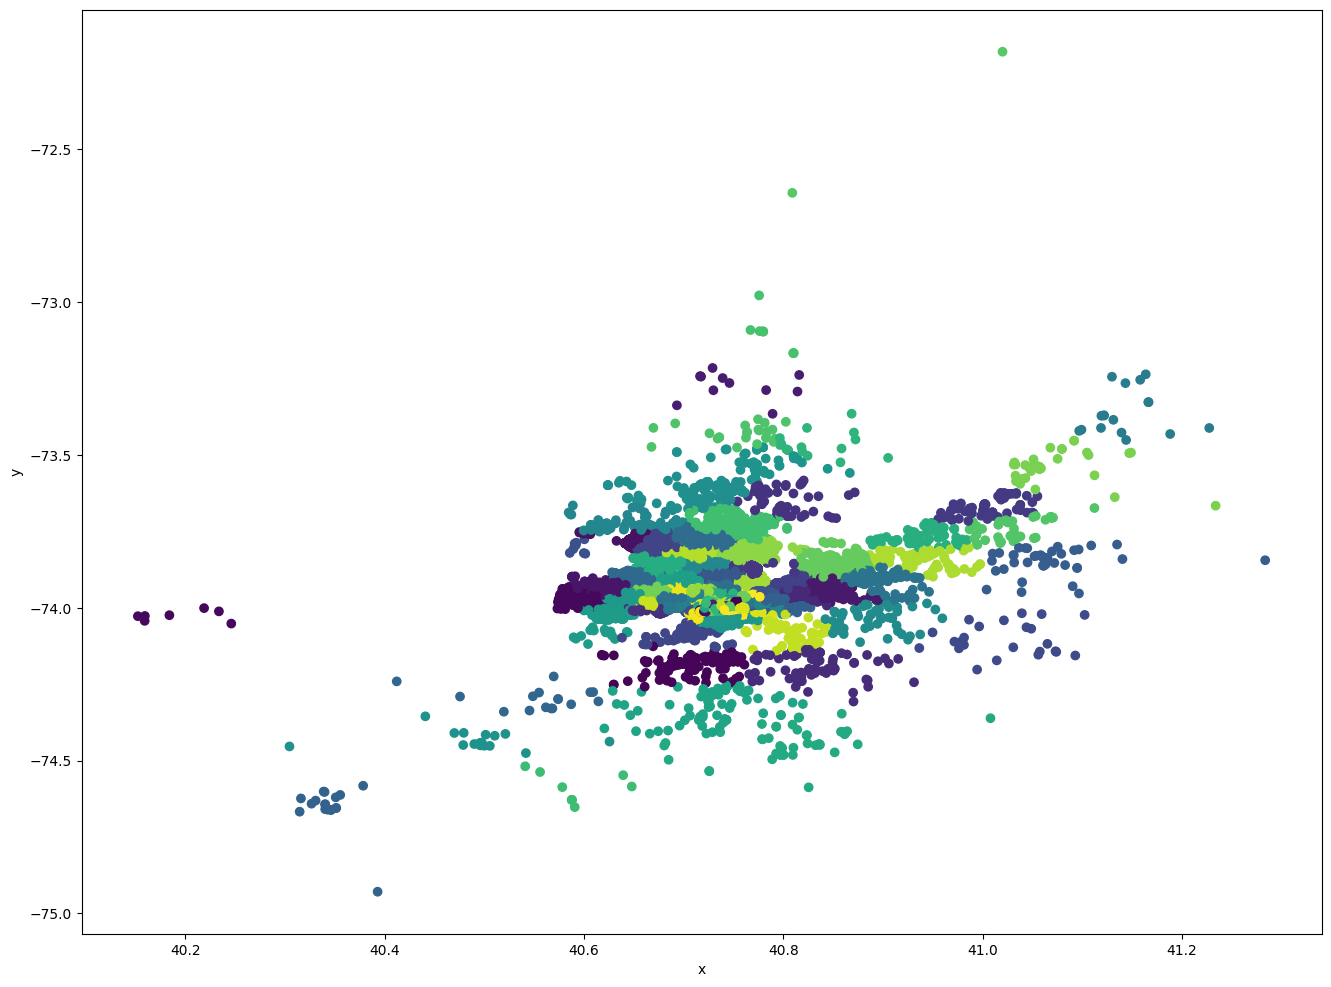

<Figure size 1200x1000 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
pddf_pred = predictDf.toPandas()
pddf_pred.head()
fig = plt.figure(figsize=(16,12))
KmVis= fig.add_subplot(111)
threedee = plt.figure(figsize=(12,10))
KmVis.scatter(pddf_pred.Lat, pddf_pred.Lon,  c=pddf_pred.prediction)
KmVis.set_xlabel('x')
KmVis.set_ylabel('y')

plt.show()

In [13]:
#save model
kmeansModel.write().overwrite().save("uber-model")
kmeansModelLoded = kmeansModel.load("uber-model")

In [14]:
df1 = spark.sparkContext.parallelize([
    ("5/1/2014 0:02:00", 40.7521, -73.9914, "B02512"),
    ("5/1/2014 0:06:00", 40.6965, -73.9715, "B02512"),
    ("5/1/2014 0:15:00", 40.7464, -73.9838, "B02512"),
    ("5/1/2014 0:17:00", 40.7463, -74.0011, "B02512"),
    ("5/1/2014 0:17:00", 40.7594, -73.9734, "B02512")]
  ).toDF(["time", "Lat", "Lon", "base"])
df1.show()

+----------------+-------+--------+------+
|            time|    Lat|     Lon|  base|
+----------------+-------+--------+------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|
+----------------+-------+--------+------+



In [15]:
df2 = assembler.transform(df1)
df2.show()

+----------------+-------+--------+------+------------------+
|            time|    Lat|     Lon|  base|          features|
+----------------+-------+--------+------+------------------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|
+----------------+-------+--------+------+------------------+



In [16]:
# prediction of sample data set with loaded model
df3 = kmeansModelLoded.transform(df2)
df3.show()

+----------------+-------+--------+------+------------------+----------+
|            time|    Lat|     Lon|  base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|        67|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|        33|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|        83|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|        88|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|         9|
+----------------+-------+--------+------+------------------+----------+

